In [4]:
#! git clone https://github.com/tapichugina/Simple_Pytorch_Img_Project.git
#! pip install torch-summary

In [14]:
%load_ext autoreload
%autoreload 2


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import torch
import torchvision
from torch import nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau,MultiStepLR, CyclicLR, LambdaLR
from torch.utils.data import Dataset, DataLoader,WeightedRandomSampler
import torchvision.datasets as datasets
from torchvision.transforms.v2 import Compose, Normalize,Resize,ToImage,ToDtype
from torch.utils.data import random_split
from torchinfo import summary

from sklearn.metrics import f1_score, confusion_matrix, classification_report



from pathlib import Path
import sys
sys.path.insert(0, str(PROJECT_ROOT))

from utils.train import StepByStep
from utils.overfit_single_batch import overfit_single_batch
from utils.calculate_img_statistics import calculate_statistics

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data

### CIFAR

size of single image
32x32x3

* Train 50000 
* Test  10000


0. 'airplane',
1. 'automobile',
2. 'bird',
3. 'cat',
4. 'deer',
5. 'dog',
6. 'frog',
7. 'horse',
8. 'ship',
9. 'truck'

In [19]:
transform = Compose([
    ToImage(),
    ToDtype(torch.float32, scale=True),
    Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))])

train_dataset = torchvision.datasets.CIFAR10(
    root="../data/CIFAR10/",
    train=True,
    transform=transform,
    download=True
)

test_dataset = torchvision.datasets.CIFAR10(
    root="../data/CIFAR10/",
    train=False,
    transform=transform,
    download=True
)

100%|██████████| 170M/170M [22:35<00:00, 126kB/s]    


In [126]:
train_loader=DataLoader(train_dataset,batch_size=128,shuffle=True)
val_loader=DataLoader(test_dataset,batch_size=128,shuffle=False)

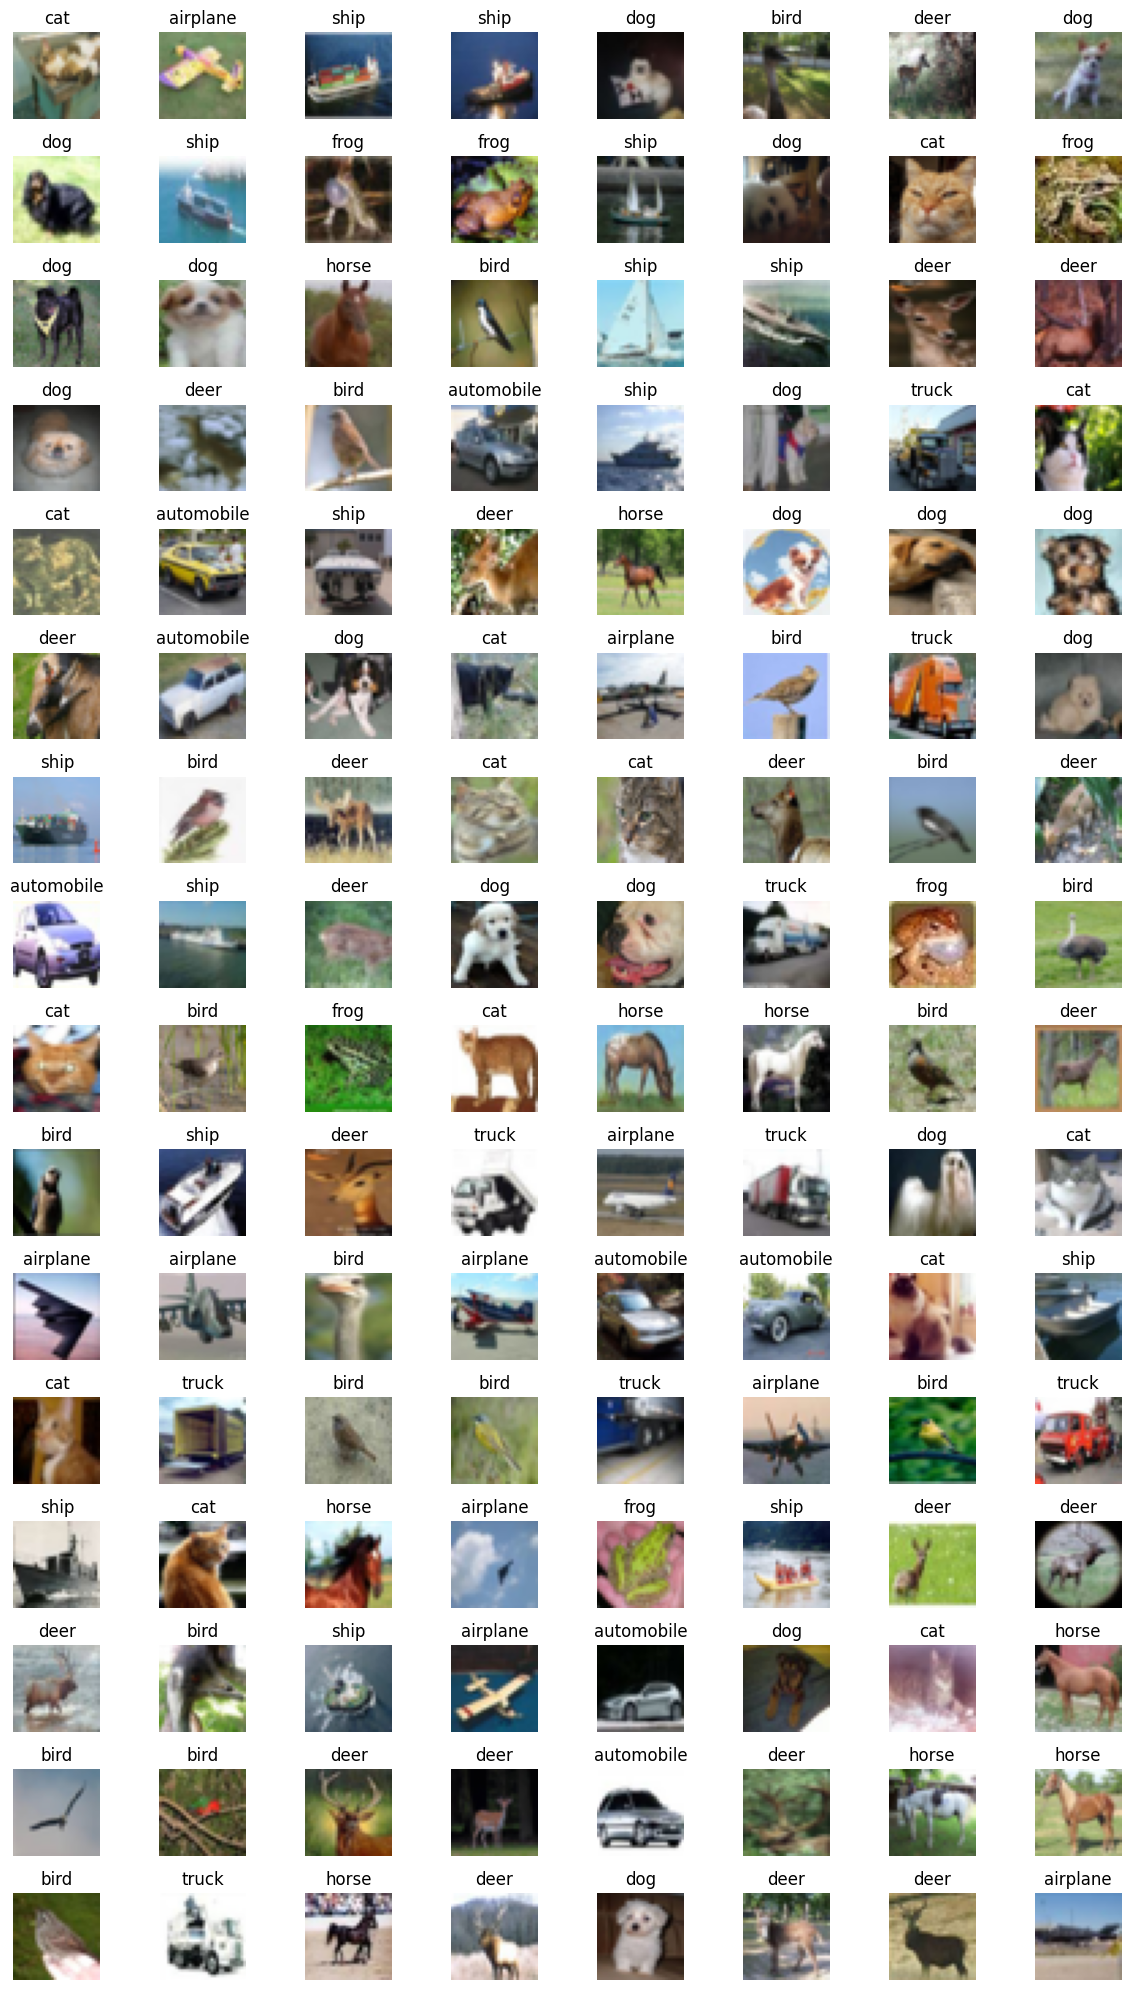

In [123]:
batch, labels = next(iter(train_loader))

mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

# Undo normalization
batch = batch * std + mean


fig, axes = plt.subplots(16, 8, figsize=(12, 20))

for image, label, ax in zip(batch, labels, axes.flat):
    image = image.permute(1, 2, 0)

    ax.imshow(image)
    ax.set_title(train_dataset.classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()


## Model

In [51]:
def vgg_block(num_convs, out_channels):
    layers = []
    for _ in range(num_convs):
        layers.append(nn.LazyConv2d(out_channels, kernel_size=3, padding=1))
        layers.append(nn.ReLU())
    layers.append(nn.MaxPool2d(kernel_size=2,stride=2))
    return nn.Sequential(*layers)


In [78]:
class small_VGG(nn.Module):
    def __init__(self, arch, num_classes=10):
        super().__init__()

        conv_blks = []
        for (num_convs, out_channels) in arch:
            conv_blks.append(vgg_block(num_convs, out_channels))
        self.net = nn.Sequential(
            *conv_blks, nn.Flatten(),
            nn.LazyLinear(4096), nn.ReLU(), nn.Dropout(0.5),
            nn.LazyLinear(4096), nn.ReLU(), nn.Dropout(0.5),
            nn.LazyLinear(num_classes))

    def forward(self, X):
        return self.net(X)

In [84]:
torch.manual_seed(13)
arch=((1,16),(2,32),(2,64))
model=small_VGG(arch)
x=torch.rand(1,3,32,32)
model(x)
summary(model, input_size=(1, 3, 32, 32))


Layer (type:depth-idx)                   Output Shape              Param #
small_VGG                                [1, 10]                   --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Sequential: 2-1                   [1, 16, 16, 16]           --
│    │    └─Conv2d: 3-1                  [1, 16, 32, 32]           448
│    │    └─ReLU: 3-2                    [1, 16, 32, 32]           --
│    │    └─MaxPool2d: 3-3               [1, 16, 16, 16]           --
│    └─Sequential: 2-2                   [1, 32, 8, 8]             --
│    │    └─Conv2d: 3-4                  [1, 32, 16, 16]           4,640
│    │    └─ReLU: 3-5                    [1, 32, 16, 16]           --
│    │    └─Conv2d: 3-6                  [1, 32, 16, 16]           9,248
│    │    └─ReLU: 3-7                    [1, 32, 16, 16]           --
│    │    └─MaxPool2d: 3-8               [1, 32, 8, 8]             --
│    └─Sequential: 2-3                   [1, 64, 4, 4]             --
│    │  

In [99]:
layers_to_hook=[model.net[0][0],model.net[1][0],model.net[2][0],model.net[7],model.net[10]]
layers_to_hook

[Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
 Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
 Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
 Linear(in_features=4096, out_features=4096, bias=True),
 Linear(in_features=4096, out_features=10, bias=True)]

In [127]:
RunName="small_VGG"
loss=nn.CrossEntropyLoss(reduction='mean')
optimizer=optim.AdamW(model.parameters(),lr=3e-4,weight_decay=1e-2)
#optimizer=optim.SGD(model_cnn2.parameters(),lr=0.025,momentum=0.9)
#scheduler=StepLR(optimizer,step_size=5,gamma=0.5)

sbs=StepByStep(model,loss,optimizer)
sbs.set_loaders(train_loader,val_loader)
#sbs.set_tensorboard(RunName)
# df=sbs.diagnostic_epoch(sbs.train_loader,layers_to_hook=layers_to_hook)
# summary=sbs.summarize_epoch(df)
# summary.to_csv(f"{RunName}_after_1 epoch)calculation.csv")
# print(summary)

In [128]:
sbs.train(1)

Epoch [0/1] -> Train Loss: 1.0503 | Val Loss: 1.0093 | F1_ score: 0.6354


In [131]:
from torch.profiler import profile, record_function, ProfilerActivity

with profile(
    activities=[
        ProfilerActivity.CPU,
        #ProfilerActivity.CUDA,
    ],
    record_shapes=True,
    profile_memory=True,
) as prof:

    x_batch, y_batch = next(iter(train_loader))

    x_batch = x_batch.to(sbs.device)
    y_batch = y_batch.to(sbs.device)

    sbs._train_step(x_batch, y_batch)

USDT:2026-10-02 10:58:17 260963:260963 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-10-02 10:58:18 260963:260963 ActivityProfilerController.cpp:455] profiler_stop


In [137]:
print(
    prof.key_averages().table(
        #sort_by="cpu_time_total",
        row_limit=30
    )
)

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                            aten::empty         0.15%     409.411us         0.15%     409.411us       1.422us      29.65 MB      29.65 MB           288  
                                          aten::random_         0.02%      42.780us         0.02%      42.780us      21.390us           0 B           0 B             2  
                                             aten::item         0.02%      61.351us         0.03%      91.721us       4.827us           0 B           

In [ ]:
# with profile(
#     activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
#     record_shapes=True,
#     profile_memory=True,
# ) as prof:

#     with record_function("TRAIN_ONE_EPOCH"):
#         sbs.train(1)

# print(
#     prof.key_averages().table(
#         sort_by="cpu_time_total",
#         row_limit=30
#     ))


/home/tatyana/Work/LearnStuff/Simple_Pytorch_Img_Project/.venv/lib/python3.12/site-packages/torch/profiler/profiler.py:254: UserWarning: CUDA is not available, disabling CUDA profiling
  self.profiler = prof.profile(
USDT:2026-10-02 11:07:10 260963:260963 ActivityProfilerController.cpp:415] profiler_start


Epoch [0/1] -> Train Loss: 0.7661 | Val Loss: 0.9841 | F1_ score: 0.6589


USDT:2026-10-02 11:08:41 260963:260963 ActivityProfilerController.cpp:455] profiler_stop


NameError: name 'prof' is not defined